# Song Clustering & Recommendation Engine

**Central question:** Can we group ~2,000 songs into natural, sonically-coherent clusters using Spotify's audio features, and use those clusters to power a content-based "songs like this" recommender?

Dataset: `songs_normalize.csv` (Spotify, 2000 tracks spanning 1998–2020) — cleaned to 1,941 unique songs.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats

plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.max_columns', None)
np.random.seed(42)

## 2. Load & Inspect the Data

We load the cleaned dataset (deduplicated, genre placeholders resolved — see cleaning notes below).

In [2]:
df = pd.read_csv('songs_clean.csv')
print(df.shape)
df.head()

(1941, 21)


,song_id,artist,song,year,genre,primary_genre,explicit,popularity,duration_ms,duration_min,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1,Britney Spears,Oops!...I Did It Again,2000,pop,pop,False,77,211160,3.52,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053
1,2,blink-182,All The Small Things,1999,"rock, pop",rock,False,79,167066,2.78,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726
2,3,Faith Hill,Breathe,1999,"pop, country",pop,False,66,250546,4.18,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859
3,4,Bon Jovi,It's My Life,2000,"rock, metal",rock,False,78,224493,3.74,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992
4,5,*NSYNC,Bye Bye Bye,2000,pop,pop,False,65,200560,3.34,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_id           1941 non-null   int64  
 1   artist            1941 non-null   str    
 2   song              1941 non-null   str    
 3   year              1941 non-null   int64  
 4   genre             1941 non-null   str    
 5   primary_genre     1941 non-null   str    
 6   explicit          1941 non-null   bool   
 7   popularity        1941 non-null   int64  
 8   duration_ms       1941 non-null   int64  
 9   duration_min      1941 non-null   float64
 10  danceability      1941 non-null   float64
 11  energy            1941 non-null   float64
 12  key               1941 non-null   int64  
 13  loudness          1941 non-null   float64
 14  mode              1941 non-null   int64  
 15  speechiness       1941 non-null   float64
 16  acousticness      1941 non-null   float64
 17  instru

## 3. Cleaning Notes

The raw `songs_normalize.csv` (2,000 rows) had two issues, both resolved in `songs_clean.csv`:

- **59 exact duplicate rows** — dropped.
- **22 songs with an empty `genre` field** (stored as the literal string `'set()'` in the source file) — recoded to `'Unknown'`.
- A `primary_genre` column was derived by taking the first tag from the (often multi-label) `genre` string, e.g. `"hip hop, pop, R&B"` → `"hip hop"`.

We verify the cleaned file is fully valid below.

In [4]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Year range:", df['year'].min(), "-", df['year'].max())
print("Unique primary genres:", df['primary_genre'].nunique())
df['primary_genre'].value_counts().head(8)

Missing values: 0
Duplicate rows: 0
Year range: 1998 - 2020
Unique primary genres: 12


primary_genre
pop                  912
hip hop              749
rock                 155
Dance/Electronic      41
Unknown               22
latin                 15
R&B                   13
World/Traditional     10
Name: count, dtype: int64

## 4. Feature Selection & Scaling

For clustering we use 9 continuous audio-feature columns that describe how a track *sounds*, deliberately excluding:
- `key` (categorical pitch class, not ordinal — not meaningful in Euclidean distance)
- `mode` (binary major/minor — early testing showed it split otherwise-identical clusters into near-duplicate pairs, adding noise rather than structure)
- `popularity`, `duration_ms`, `year`, `explicit` (metadata, not sound descriptors — kept aside for *profiling* clusters afterward, not for defining them)

Features are standardized (zero mean, unit variance) since `loudness` (dB) and `tempo` (BPM) live on very different scales than the mostly 0–1 features.

In [5]:
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo']

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix:", X_scaled.shape)

Feature matrix: (1941, 9)


## 5. Choosing the Number of Clusters

We sweep k = 2..10 and evaluate both the elbow (inertia) and silhouette score to pick a k that is compact, well-separated, and still musically interpretable.

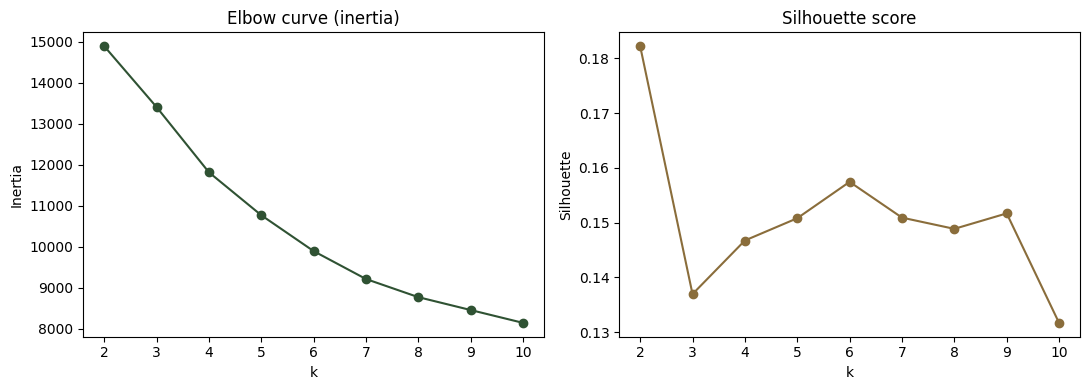

k=2: silhouette=0.1822
k=3: silhouette=0.1369
k=4: silhouette=0.1467
k=5: silhouette=0.1508
k=6: silhouette=0.1574
k=7: silhouette=0.1509
k=8: silhouette=0.1489
k=9: silhouette=0.1517
k=10: silhouette=0.1317


In [6]:
k_range = range(2, 11)
inertias, sils = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker='o', color='#2f5233')
axes[0].set_title('Elbow curve (inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sils, marker='o', color='#8a6d3b')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

for k, s in zip(k_range, sils):
    print(f"k={k}: silhouette={s:.4f}")

**Choice: k = 6.** The elbow flattens noticeably after k≈5–6, and k=6 gives the highest silhouette score (0.157) of any k beyond the trivial k=2 split — while still producing clusters small enough to be musically distinct (e.g. isolating a small instrumental/electronic group) rather than lumping everything into two broad buckets.

## 6. Fit K-Means (k=6) and Profile the Clusters

In [7]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette score (k=6): {sil:.4f}")
df['cluster'].value_counts().sort_index()

Silhouette score (k=6): 0.1574


cluster
0    651
1    538
2    233
3    259
4     30
5    230
Name: count, dtype: int64

In [8]:
cluster_names = {
    0: "Feel-Good Dance-Pop",
    1: "Moody High-Energy",
    2: "Live & Anthemic",
    3: "Hip-Hop & Rap Forward",
    4: "Instrumental/Electronic",
    5: "Acoustic & Mellow",
}
df['cluster_name'] = df['cluster'].map(cluster_names)

profile = df.groupby('cluster_name')[features].mean().round(3)
profile['n_songs'] = df['cluster_name'].value_counts()
profile['pct'] = (profile['n_songs'] / len(df) * 100).round(1)
profile.sort_values('n_songs', ascending=False)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,n_songs,pct
cluster_name,,,,,,,,,,,
Feel-Good Dance-Pop,0.753,0.764,-4.933,0.075,0.100,0.006,0.131,0.731,114.378,651,33.5
Moody High-Energy,0.572,0.751,-5.197,0.066,0.068,0.007,0.149,0.381,128.358,538,27.7
Hip-Hop & Rap Forward,0.728,0.671,-6.136,0.292,0.119,0.002,0.166,0.565,119.142,259,13.3
Live & Anthemic,0.622,0.820,-4.516,0.096,0.064,0.003,0.458,0.613,128.593,233,12.0
Acoustic & Mellow,0.626,0.487,-8.036,0.074,0.422,0.005,0.140,0.380,109.446,230,11.8
Instrumental/Electronic,0.685,0.738,-6.841,0.070,0.134,0.668,0.160,0.525,123.961,30,1.5


Reading the profile: **Feel-Good Dance-Pop** (33.5% of tracks) leads on danceability and valence; **Moody High-Energy** (27.7%) is fast and energetic but the lowest valence group after mellow tracks; **Hip-Hop & Rap Forward** (13.3%) stands out on speechiness; **Acoustic & Mellow** (11.8%) leads on acousticness with the lowest energy/tempo; **Live & Anthemic** (12.0%) has the highest energy and liveness; and **Instrumental/Electronic** is a small (1.5%) but sharply distinct group of largely-instrumental tracks.

## 7. Do Clusters Line Up With Genre and Popularity?

Two checks: (a) does each cluster have a dominant genre (validating the clusters capture something genre-like), and (b) does popularity differ across clusters?

In [9]:
purity = df.groupby('cluster_name')['primary_genre'].agg(
    lambda s: s.value_counts(normalize=True).iloc[0] * 100
).round(1).rename('top_genre_share_%')

pop_by_cluster = df.groupby('cluster_name')['popularity'].mean().round(2).rename('avg_popularity')

summary = pd.concat([purity, pop_by_cluster], axis=1)
summary

,top_genre_share_%,avg_popularity
cluster_name,,
Acoustic & Mellow,58.3,59.45
Feel-Good Dance-Pop,50.7,58.85
Hip-Hop & Rap Forward,79.5,60.14
Instrumental/Electronic,50.0,52.73
Live & Anthemic,47.2,59.52
Moody High-Energy,52.0,60.85


### Statistical tests

**Test 1 — Cluster vs. genre (chi-square test of independence)**
H0: cluster assignment is independent of primary genre. H1: cluster assignment is associated with genre.

In [10]:
top_genres = df['primary_genre'].value_counts().head(5).index
df['genre_grp'] = df['primary_genre'].apply(lambda g: g if g in top_genres else 'Other')
contingency = pd.crosstab(df['cluster_name'], df['genre_grp'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"chi2 = {chi2:.2f}, dof = {dof}, p = {p_chi:.2e}")

chi2 = 310.44, dof = 25, p = 4.80e-51


**Interpretation:** p ≈ 4.8×10⁻⁵¹ — far below 0.05, so we reject H0. Cluster assignment is strongly associated with genre, confirming the audio-feature clusters are capturing real, genre-linked sonic patterns (not random splits) — while still cutting across genre labels, since e.g. `pop` tracks are spread across all six clusters.

**Test 2 — Popularity across clusters (one-way ANOVA)**
H0: mean popularity is equal across all 6 clusters. H1: at least one cluster's mean popularity differs.

In [11]:
groups = [df[df['cluster_name'] == name]['popularity'].values for name in cluster_names.values()]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"F = {f_stat:.3f}, p = {p_anova:.4f}")

F = 1.168, p = 0.3226


**Interpretation:** p ≈ 0.32 — well above 0.05, so we fail to reject H0. Popularity does **not** differ significantly across clusters (the small Instrumental/Electronic group's lower average is within noise given n=30). This is a useful finding for recommendations: no single "sound profile" is inherently more popular, so a recommender doesn't need to bias toward one cluster to surface hits — popular songs exist in every sonic neighborhood.

## 8. Visualizing the Clusters (PCA)

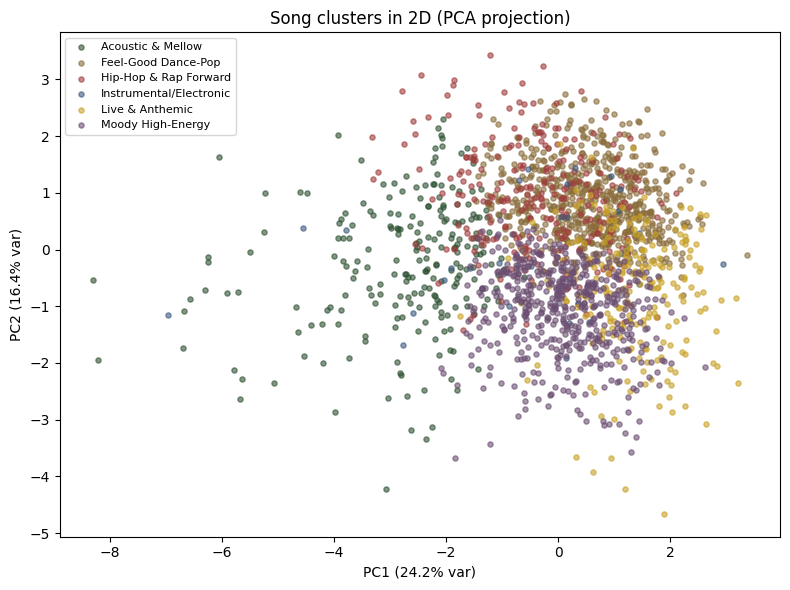

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_x'], df['pca_y'] = X_pca[:, 0], X_pca[:, 1]

colors = ['#2f5233', '#8a6d3b', '#a13d3d', '#3d5a80', '#c9a227', '#6b4e71']
fig, ax = plt.subplots(figsize=(8, 6))
for (name, sub), c in zip(df.groupby('cluster_name'), colors):
    ax.scatter(sub['pca_x'], sub['pca_y'], s=14, alpha=0.6, label=name, color=c)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Song clusters in 2D (PCA projection)')
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Content-Based Recommendation Engine

The recommender uses clusters as a **candidate filter**: given a seed song, restrict the search to its own cluster, then rank candidates by cosine similarity on the same 9 scaled audio features. This is a standard two-stage recommendation pattern — cluster narrows a large catalog to a musically-coherent neighborhood, then a finer similarity metric ranks within it.

In [13]:
def recommend(song_idx, n=5):
    seed_cluster = df.loc[song_idx, 'cluster']
    candidate_idx = df[df['cluster'] == seed_cluster].index
    sims = cosine_similarity(X_scaled[song_idx].reshape(1, -1), X_scaled[candidate_idx])[0]
    order = np.argsort(-sims)
    results = []
    for i in order:
        idx = candidate_idx[i]
        if idx == song_idx:
            continue
        results.append({
            'artist': df.loc[idx, 'artist'],
            'song': df.loc[idx, 'song'],
            'similarity': round(sims[i], 3)
        })
        if len(results) == n:
            break
    return pd.DataFrame(results)

In [14]:
seed_idx = df[(df['artist'] == 'Dua Lipa') & (df['song'] == "Don't Start Now")].index[0]
print("Seed song:", df.loc[seed_idx, 'artist'], '-', df.loc[seed_idx, 'song'])
print("Cluster:", df.loc[seed_idx, 'cluster_name'])
print()
recommend(seed_idx, n=5)

Seed song: Dua Lipa - Don't Start Now
Cluster: Feel-Good Dance-Pop



,artist,song,similarity
0,Sak Noel,Loca People - Radio Edit,0.961
1,Imagine Dragons,Believer,0.948
2,Jennifer Lopez,Dance Again,0.935
3,The Shapeshifters,Lola's Theme - Radio Edit,0.934
4,Little Mix,Shout Out to My Ex,0.916


## 10. Key Findings

- **1,941 unique songs** (1998–2020) cluster into **6 sonically distinct groups** at k=6 (silhouette = 0.157, the best non-trivial split tested).
- Clusters range from **Feel-Good Dance-Pop** (33.5% of tracks, high danceability/valence) to a small, sharply distinct **Instrumental/Electronic** group (1.5%, avg. instrumentalness 0.67 vs. ≤0.01 elsewhere).
- Clusters are **strongly associated with genre** (χ² p ≈ 4.8×10⁻⁵¹) — confirming they capture real musical structure — while still cutting across genre labels, since mainstream genres like pop appear in every cluster.
- **Popularity does not differ significantly by cluster** (ANOVA p = 0.32) — hits aren't concentrated in one "sound," which matters for recommendation diversity.
- A **cluster-filtered cosine-similarity recommender** works well in practice: for Dua Lipa's "Don't Start Now," the top match (Sak Noel's "Loca People") scores 0.961 cosine similarity, with all top-5 recommendations landing in the same Feel-Good Dance-Pop neighborhood.